## Содержание

- [Работа с корпусом данных](#данные)
- [Сравнение архитектур GRU](#сравнение-архитектур-gru)
- [Подбор гиперпараметров и тестирование лучшей модели](#подбор-гиперпараметров)
- [Анализ результатов](#матрица-ошибок)
- [Выводы](#результаты)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

### Данные

In [3]:
data = pd.read_csv('Free_Text_Typing_Dataset.csv', sep=';', decimal=',')

print(data.shape)
data.head()

(28412, 15)


,_id,userid,emotionIndex,index,keyCode,keyDown,keyUp,D1U1,D1U2,D1D2,U1D2,U1U2,D1U3,D1D3,answer
0,5e1e2631d2dd163d472fd5ac,100,N,822,\u0011,1.579030e+12,1.579030e+12,9.820000e+02,7.640000e+02,709.0,-2.730000e+02,-2.180000e+02,-1.579030e+12,24124.0,NaN
1,5e1e2631d2dd163d472fd5ad,100,N,823,v,1.579030e+12,1.579030e+12,5.500000e+01,-1.579030e+12,23415.0,2.336000e+04,-1.579030e+12,-1.579030e+12,24022.0,NaN
2,5e1e2631d2dd163d472fd5ae,100,N,824,\b,1.579030e+12,NaN,-1.579030e+12,-1.579030e+12,607.0,1.579030e+12,0.000000e+00,-1.579030e+12,642.0,NaN
3,5e1e2631d2dd163d472fd5af,100,N,825,\b,1.579030e+12,NaN,-1.579030e+12,-1.579030e+12,35.0,1.579030e+12,0.000000e+00,-1.579030e+12,77.0,NaN
4,5e1e2631d2dd163d472fd5b0,100,N,826,\b,1.579030e+12,NaN,-1.579030e+12,-1.579030e+12,42.0,1.579030e+12,0.000000e+00,-1.579030e+12,79.0,NaN


- `Emotion Index`: H (Happy), S (Sad), A (Angry), C (Calm), N (Neutral state)
- `Key Code`: клавиша, нажатая участником
- `Key Down`: точная временная метка события нажатия клавиши
- `Key Up`: точное временная метка, когда клавиша была отпущена
- `D1U1`: время от 1-го нажатия до 1-го отпускания
- `D1U2`: время от 1-го нажатия до 2-го отпускания
- `D1D2`: время от 1-го нажатия до 2-го нажатия
- `U1D2`: Время от 1-го отпускания до 2-го нажатия
- `U1U2`: время от 1-го отпускания до 2-го отпускания
- `D1U3`: время от 1-го нажатия до 3-го отпускания
- `D1D3`: время от 1-го нажатия до 3-го нажатия


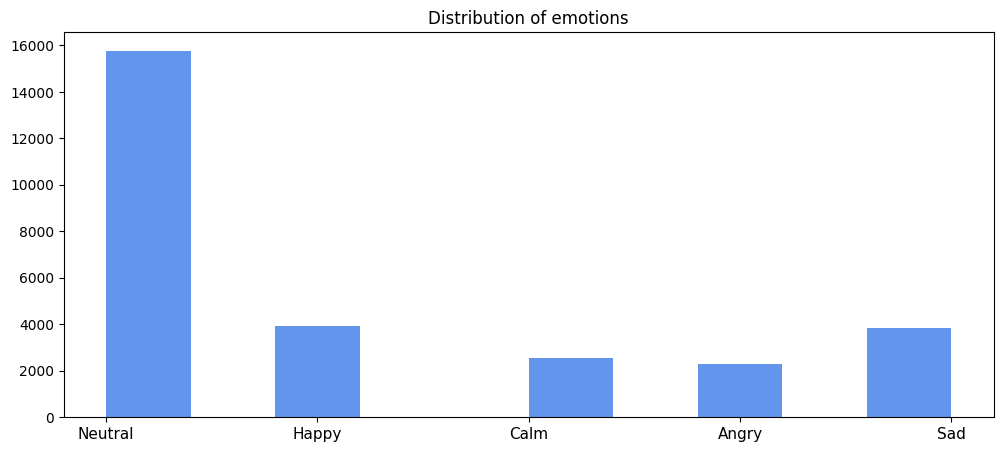

In [4]:
plt.figure(figsize=(12, 5))
plt.title('Distribution of emotions')
plt.hist(data['emotionIndex'], color='cornflowerblue')
plt.xticks([0, 1, 2, 3, 4], ['Neutral', 'Happy', 'Calm', 'Angry', 'Sad'],fontsize=11)
plt.show()

In [5]:
data = data.drop(columns=['_id', 'answer']) # эти колонки не понадобятся

In [6]:
data['keyCode'].unique()

array(['\\u0011', 'v', '\\b', ' ', 'm', 'y', 'd', 'a', 'w', 's', 'o', 'n',
       'i', 'p', 'e', 't', 'l', 'h', 'g', '¼', 'c', 'u', 'r', 'x', 'b',
       '\\u0014', '4', 'f', 'k', '\\u0010', '¾', '6', '¿', 'û', 'ß', '%',
       "'", '&', '\\r', '.', 'j', 'å', '9', '0', 'þ', 'º', '7', '3', '1',
       '»', '8', 'q', '`', '5', '©', nan, 'â', 'z', 'à', '2', '¡', '#',
       'ü', '\\u0012', '\x90', 'ý', '(', '½'], dtype=object)

Добавим признаки:
- `is_punctuation`: бинарный флаг (усталость $\rightarrow$ пауза после точки/запятой увеличивается)
- `is_backspace`: бинарный флаг для Backspace (Delete)
- `is_enter`: бинарный флаг для Enter

In [7]:
punctuation = [',', '.', '?', '!']
data['is_punctuation'] = data['keyCode'].apply(lambda a: a in punctuation).astype(int)

data['is_backspace'] = (data['keyCode'] == '\\b').astype(int)
data['is_enter'] = (data['keyCode'] == '\\r').astype(int)

In [8]:
data['keyDown'] = pd.to_datetime(data['keyDown'], unit='ms')
data['keyUp'] = pd.to_datetime(data['keyUp'], unit='ms')

data['hour'] = data['keyDown'].dt.hour

In [9]:
data = data.drop(columns=['keyUp', 'keyDown', 'keyCode'])
data = data.dropna()

print(data.shape)
data.head()

(27938, 14)


,userid,emotionIndex,index,D1U1,D1U2,D1D2,U1D2,U1U2,D1U3,D1D3,is_punctuation,is_backspace,is_enter,hour
0,100,N,822,9.820000e+02,7.640000e+02,709.0,-2.730000e+02,-2.180000e+02,-1.579030e+12,24124.0,0,0,0,19.0
1,100,N,823,5.500000e+01,-1.579030e+12,23415.0,2.336000e+04,-1.579030e+12,-1.579030e+12,24022.0,0,0,0,19.0
2,100,N,824,-1.579030e+12,-1.579030e+12,607.0,1.579030e+12,0.000000e+00,-1.579030e+12,642.0,0,1,0,19.0
3,100,N,825,-1.579030e+12,-1.579030e+12,35.0,1.579030e+12,0.000000e+00,-1.579030e+12,77.0,0,1,0,19.0
4,100,N,826,-1.579030e+12,-1.579030e+12,42.0,1.579030e+12,0.000000e+00,-1.579030e+12,79.0,0,1,0,19.0


In [10]:
y_encoder = LabelEncoder()
y_encoder.fit(data['emotionIndex'].unique().tolist()) 

data['emotionIndex'] = y_encoder.transform(data['emotionIndex']) # кодируем буквенные значения в численные 

In [11]:
data.to_csv('Free_Text_EmoSurv.csv')

In [12]:
data.columns

Index(['userid', 'emotionIndex', 'index', 'D1U1', 'D1U2', 'D1D2', 'U1D2',
       'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter',
       'hour'],
      dtype='object')

Делим выборку в соотношении 70:15:15

- 70% - train
- 15% - test
- 15% - validation (для подбора гиперпараметров)

In [13]:
users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

In [14]:
test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

Видим сильный дисбаланс классов на выборках:

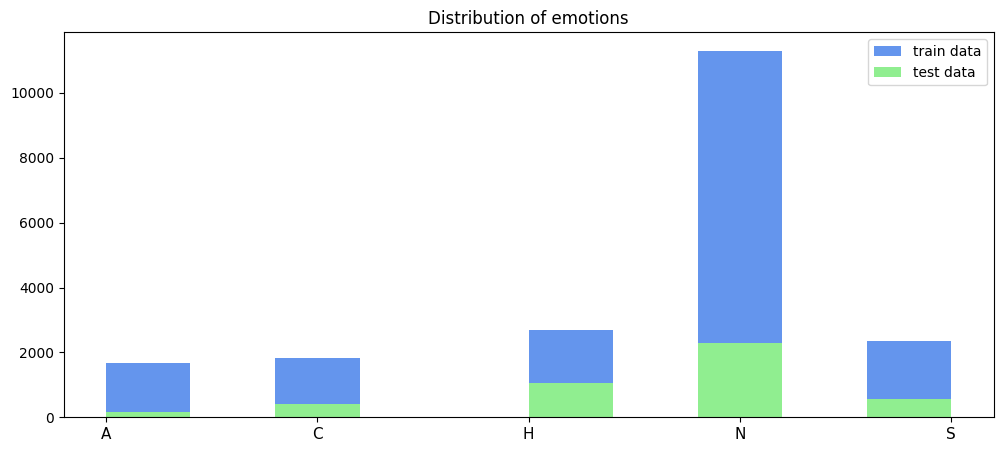

In [15]:
plt.figure(figsize=(12, 5))
plt.hist(train_data['emotionIndex'], color='cornflowerblue', label='train data')
plt.hist(test_data['emotionIndex'], color='lightgreen', label='test data')
plt.title('Distribution of emotions')
plt.xticks([0, 1, 2, 3, 4], y_encoder.classes_, fontsize=11)
plt.legend()
plt.show()

Нормализуем данные (обучаем только на train)

In [16]:
feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

In [17]:
def create_sequences(data, seq_length, step, is_train = False):
    X, y = [], []

    st = step if is_train else seq_length

    for id in data['userid'].unique():
        user_data = data[data['userid'] == id].sort_values('index')        
        user_X = user_data.drop(columns=['emotionIndex', 'index', 'userid']).values
        user_y = user_data['emotionIndex'].values

        if len(user_data) < seq_length + 1:
            continue

        for j in range(0, len(user_data) - seq_length, st):
            X.append(user_X[j:j+seq_length])
            y.append(user_y[j+seq_length])

    X = np.array(X, dtype = np.float32)
    y = np.array(y, dtype=np.int64)
    
    return torch.FloatTensor(X), torch.LongTensor(y)

Для чего нужен STEP:

- Модель учится предсказывать в любой момент, а не только через каждые seq_len нажатия _(т.е. она будет видеть разные "срезы" данных и учится более обобщённым паттернам)_
    - без перекрытия нужно по нажатиям 1-32 предсказать 33, по нажатиям 33-64 предсказать 65
    - с перекрытием (step=16) нужно по нажатиям 1-32 предсказать 33, по нажатиям 17-48 предсказать 49 и тд
- Снижение влияния границ окон
    - если важное событие происходит на стыке окон (например, эмоция меняется), без перекрытия можем его пропустить, а с перекрытием оно попадёт в несколько окон

In [18]:
SEQ_LEN = 32  # длина последовательности
STEP = 16     # шаг для последовательности
X_train, y_train = create_sequences(train_data, SEQ_LEN, STEP, is_train = True)
X_test, y_test = create_sequences(test_data, SEQ_LEN, STEP)
X_valid, y_valid = create_sequences(valid_data, SEQ_LEN, STEP)

In [19]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [20]:
# вычисляем веса для классов (обратно пропорционально частоте)
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2, 3, 4]),
    y=y_train.numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [21]:
X_train.shape # [batch, seq_len, n_features]

torch.Size([1155, 32, 11])

Делим данные на батчи

In [22]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)  
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False) 
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)   

## Сравнение архитектур GRU

In [23]:
class DetectorGRU(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 32, num_layers = 2, num_classes = 1, dropout = 0.1, bidirectional = False):
        super(DetectorGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout,
            bidirectional = bidirectional
        )
        if bidirectional:
            self.fc = nn.Linear(2 * hidden_size, num_classes)
        else:
            self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        #h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_() 
        out, h_n = self.gru(x)
        out = self.fc(out[:, -1, :]) # последний выход для каждого примера
        return out

In [24]:
def model_analysis(model, total_epochs, model_optimizer, criterion):
    train_f1 = []
    train_loss = []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        targets, predictions = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            model_optimizer.zero_grad()
            output = model(X_batch)
            
            loss = criterion(output, y_batch)
            loss.backward()
            model_optimizer.step()

            preds = torch.argmax(output, dim = 1)
            total_loss += loss.item() * X_batch.size(0)
            targets.extend(y_batch.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
        
        avg_loss = total_loss / len(train_loader.dataset)
        train_loss.append(avg_loss)
        f1 = f1_score(targets, predictions, average='macro')
        train_f1.append(f1)
        
        if epoch % 10 == 9 or epoch == 0:
            print(f'Epoch {epoch+1}/{total_epochs}, Loss: {avg_loss:.6f}')
        
    return train_loss, train_f1

In [25]:
def plot_train_dynamics(model, train_loss, train_f1, title):
    fig, axs = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(title, fontweight='bold')

    axs[0].plot(train_loss, color='royalblue')
    axs[0].set_xlabel('epoch')
    axs[0].set_ylabel('loss')
    axs[0].set_title('Loss dynamics')


    all_weights = []
    for param in model.parameters():
        if param.requires_grad:
            all_weights.extend(param.detach().numpy().flatten())

    axs[1].plot(train_f1, color='teal')
    axs[1].set_title('F1 score dynamics')
    axs[1].set_xlabel('epoch')
    axs[1].set_ylabel('f1_score')

    plt.show()

In [26]:
NUM_EPOCHS = 30

In [27]:
base_model = DetectorGRU(input_size = 11, hidden_size = 64, num_layers = 2, num_classes = 5, dropout = 0.2, bidirectional = False).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight = class_weights)
optimizer = optim.Adam(base_model.parameters(), lr = 0.001)

train_loss_base, train_f1_base = model_analysis(base_model, NUM_EPOCHS, optimizer, criterion)

Epoch 1/30, Loss: 1.614201
Epoch 10/30, Loss: 1.515289
Epoch 20/30, Loss: 1.454153
Epoch 30/30, Loss: 1.376614


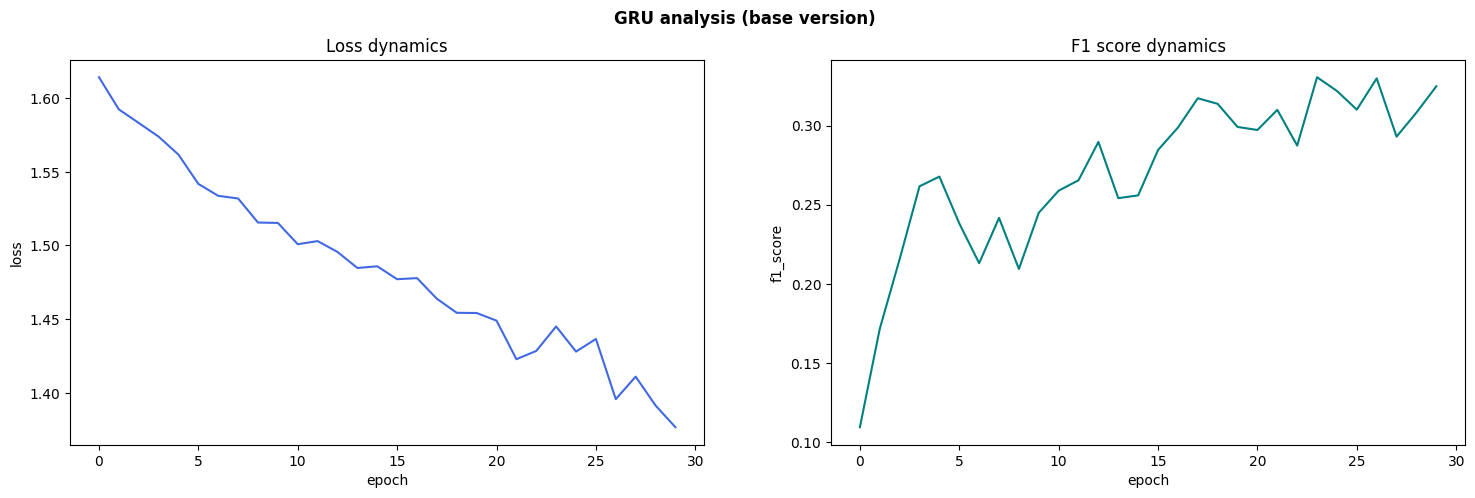

In [28]:
plot_train_dynamics(base_model, train_loss_base, train_f1_base, 'GRU analysis (base version)')

In [29]:
model_bidirect = DetectorGRU(input_size = 11, hidden_size = 64, num_layers = 2, num_classes = 5, dropout = 0.2, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(model_bidirect.parameters(), lr = 0.001)

train_loss_bidirect, train_f1_bidirect = model_analysis(model_bidirect, NUM_EPOCHS, optimizer, criterion)

Epoch 1/30, Loss: 1.606895
Epoch 10/30, Loss: 1.497634
Epoch 20/30, Loss: 1.464899
Epoch 30/30, Loss: 1.364944


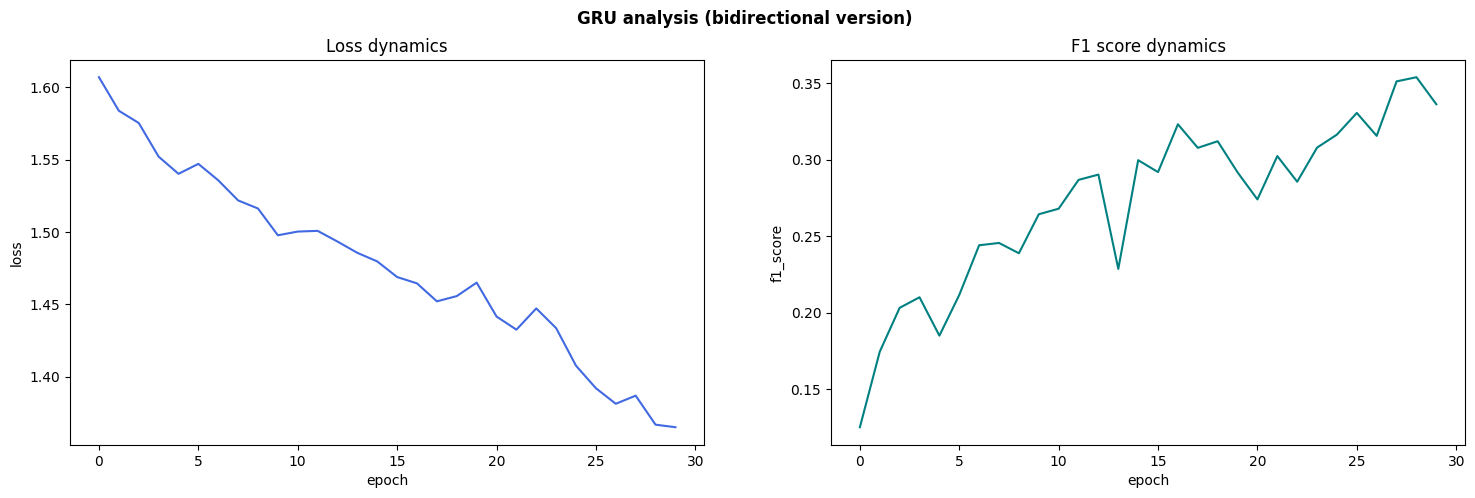

In [30]:
plot_train_dynamics(model_bidirect, train_loss_bidirect, train_f1_bidirect, 'GRU analysis (bidirectional version)')

In [31]:
class DetectorAttentionGRU(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 32, num_layers = 2, num_classes = 1, dropout = 0.1, bidirectional = False):
        super(DetectorAttentionGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout,
            bidirectional = bidirectional
        )

        self.output_size = hidden_size * (2 if bidirectional else 1)

        self.attention = nn.Sequential(
            nn.Linear(self.output_size, 1)
        )

        self.fc = nn.Linear(self.output_size, num_classes) 

        
    def forward(self, x):
        #h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_() 
        out, h_n = self.gru(x)

        attn = self.attention(out)
        attention_weights = F.softmax(attn, dim = 1)

        context = torch.sum(attention_weights * out, dim = 1)  # [batch_size, output_size]
        context = self.dropout(context)
        output = self.fc(context)

        return output

In [32]:
attn_model = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 2, num_classes = 5, dropout = 0.2, bidirectional = False).to(DEVICE)
optimizer = optim.Adam(attn_model.parameters(), lr = 0.001)

train_loss_attn, train_f1_attn = model_analysis(attn_model, NUM_EPOCHS, optimizer, criterion)

Epoch 1/30, Loss: 1.610792
Epoch 10/30, Loss: 1.521703
Epoch 20/30, Loss: 1.472163
Epoch 30/30, Loss: 1.412489


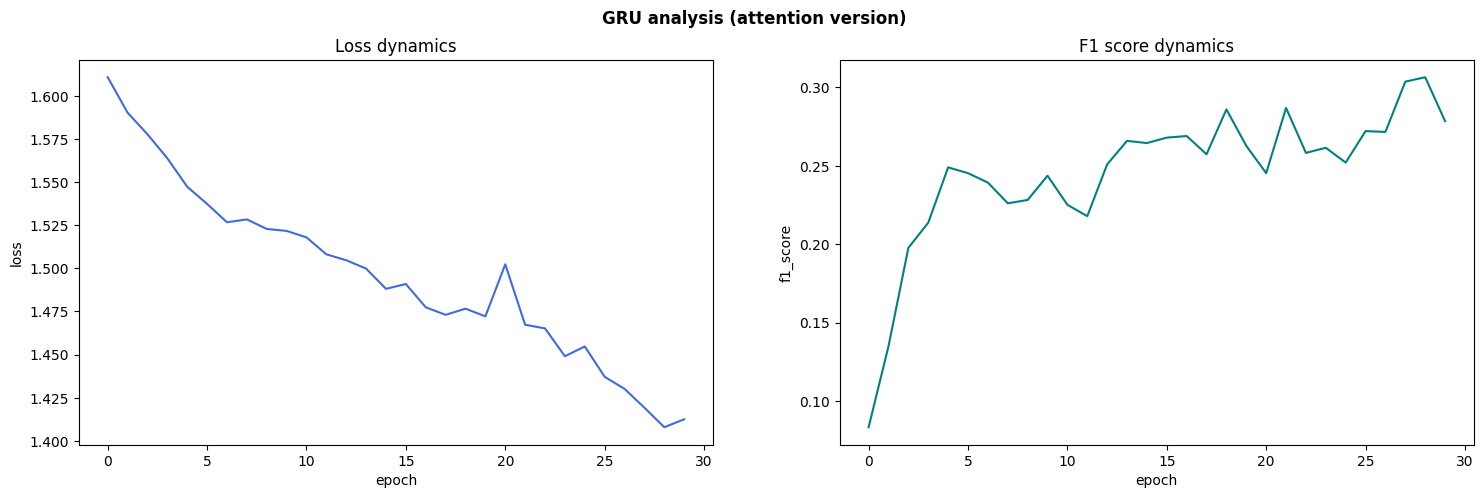

In [33]:
plot_train_dynamics(attn_model, train_loss_attn, train_f1_attn, 'GRU analysis (attention version)')

In [34]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 2, num_classes = 5, dropout = 0.2, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.001)

train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, NUM_EPOCHS, optimizer, criterion)

Epoch 1/30, Loss: 1.600748
Epoch 10/30, Loss: 1.514522
Epoch 20/30, Loss: 1.411559
Epoch 30/30, Loss: 1.290398


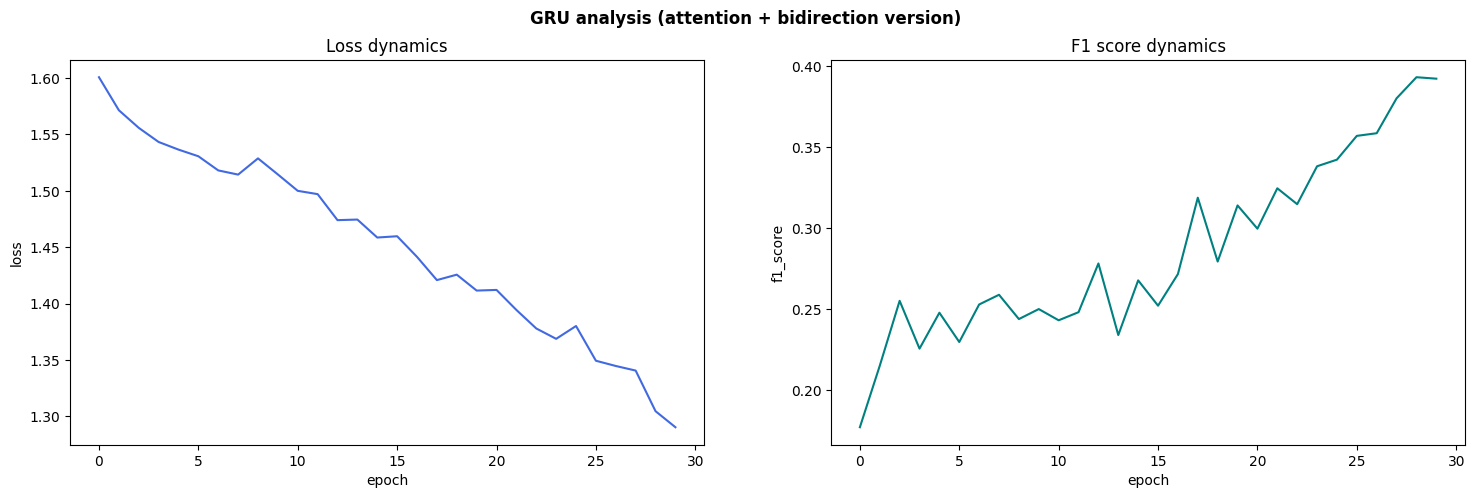

In [35]:
plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')

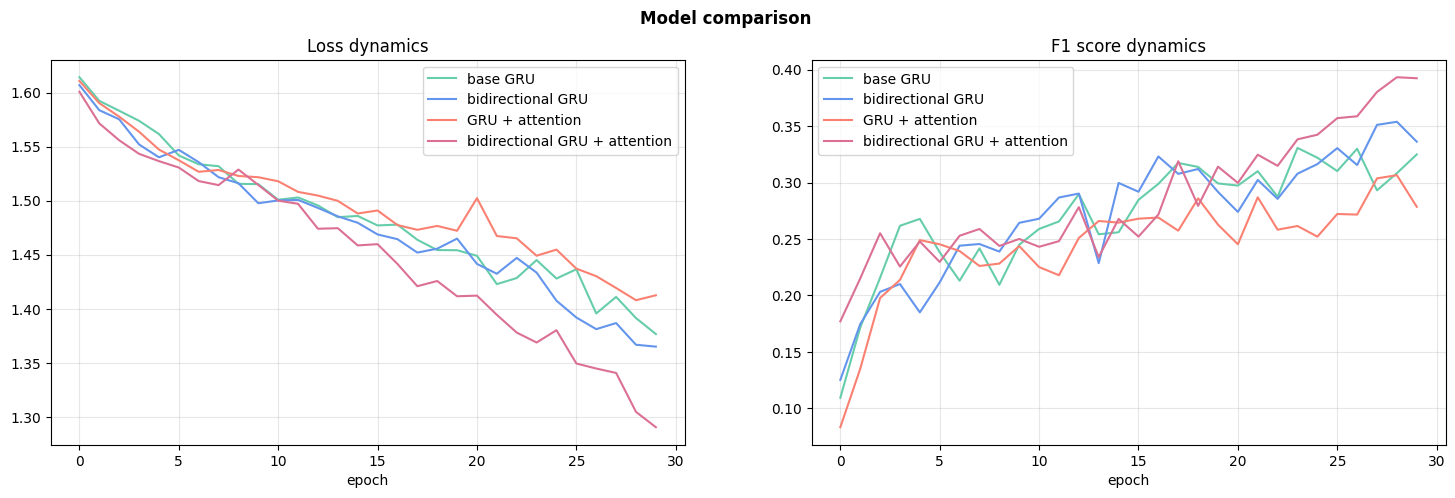

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Model comparison', fontweight='bold')

clr = ['mediumaquamarine', 'cornflowerblue', 'salmon', 'palevioletred']

axs[0].set_title('Loss dynamics')
axs[0].plot(train_loss_base, label='base GRU', color=clr[0])
axs[0].plot(train_loss_bidirect, label='bidirectional GRU', color=clr[1])
axs[0].plot(train_loss_attn, label='GRU + attention', color=clr[2])
axs[0].plot(train_loss_attn_b, label='bidirectional GRU + attention', color=clr[3])
axs[0].set_xlabel('epoch')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].set_title('F1 score dynamics')
axs[1].plot(train_f1_base, label='base GRU', color=clr[0])
axs[1].plot(train_f1_bidirect, label='bidirectional GRU', color=clr[1])
axs[1].plot(train_f1_attn, label='GRU + attention', color=clr[2])
axs[1].plot(train_f1_attn_b, label='bidirectional GRU + attention', color=clr[3])
axs[1].set_xlabel('epoch')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

## Подбор гиперпараметров

In [37]:
import optuna

In [38]:
def validate(model, val_loader):
    model.eval()  # режим оценки (выключаем dropout, batch norm)
    all_preds = []
    all_targets = []
    
    with torch.no_grad(): 
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)  
            preds = torch.argmax(output, dim = 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
    
    f1 = f1_score(all_targets, all_preds, average='macro')
    return f1

In [63]:
def objective(trial):
    learning_rate = trial.suggest_float('learning rate', 1e-4, 1e-2, log = True)
    hidden_size = trial.suggest_int('hidden_size', 64, 256, step = 16)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)

    model = DetectorAttentionGRU(input_size = 11, hidden_size = hidden_size, 
                                 num_layers = num_layers, num_classes = 5, dropout = dropout, bidirectional = True).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr = learning_rate)

    # обучаем с ранней остановкой 
    best_val_f1 = 0
    patience_counter = 0

    for epoch in range(30):
        model.train()
        for X_batch, y_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
        
                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                optimizer.step()
        
        # валидируем на каждой эпохе
        val_f1 = validate(model, valid_loader)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 4:
                break

    return best_val_f1


study = optuna.create_study(direction='maximize', study_name='GRU_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials = 30)

trial = study.best_trial

print("Best F1 score: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Best F1 score: 0.3610964000437685
Best hyperparameters: {'learning rate': 0.005120721220169272, 'hidden_size': 64, 'num_layers': 3, 'dropout': 0.22739825351943735}


In [64]:
best_attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 64, num_layers = 3,  num_classes = 5, dropout = 0.227, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(best_attn_model_bidirect.parameters(), lr = 0.005)

In [65]:
train_loss_, train_f1_ = model_analysis(best_attn_model_bidirect, 20, optimizer, criterion)

Epoch 1/20, Loss: 1.615256
Epoch 10/20, Loss: 1.473530
Epoch 20/20, Loss: 1.226150


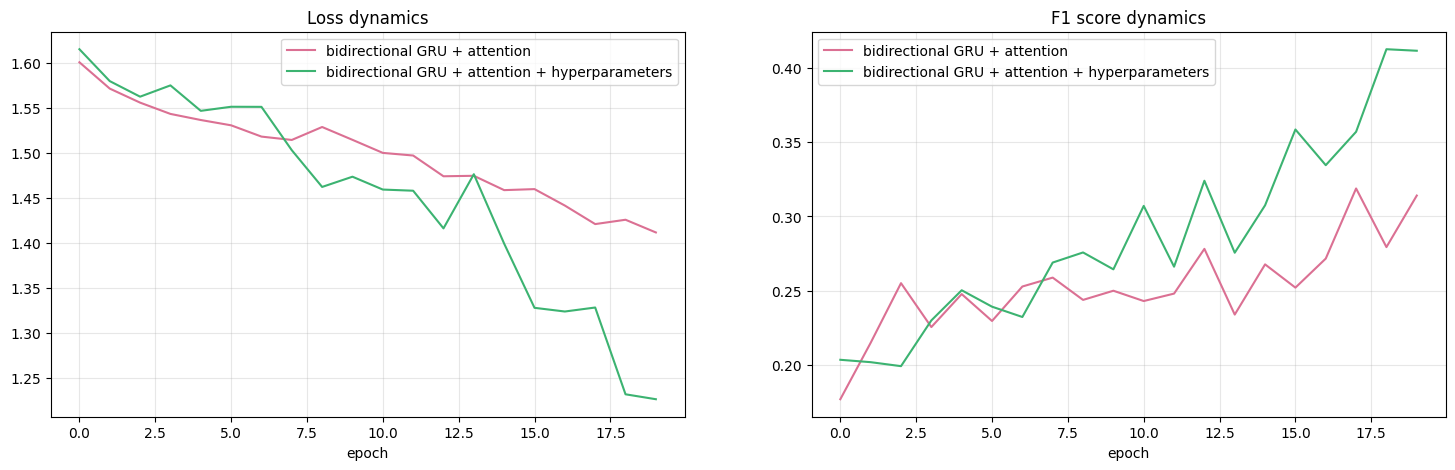

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(18, 5))

axs[0].set_title('Loss dynamics')
axs[0].plot(train_loss_attn_b[:20], label='bidirectional GRU + attention', color=clr[3])
axs[0].plot(train_loss_, label='bidirectional GRU + attention + hyperparameters', color='mediumseagreen')
axs[0].set_xlabel('epoch')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].set_title('F1 score dynamics')
axs[1].plot(train_f1_attn_b[:20], label='bidirectional GRU + attention', color=clr[3])
axs[1].plot(train_f1_, label='bidirectional GRU + attention + hyperparameters', color='mediumseagreen')
axs[1].set_xlabel('epoch')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.show()

In [67]:
validate(best_attn_model_bidirect, test_loader)

0.22245631713649333

#### Матрица ошибок

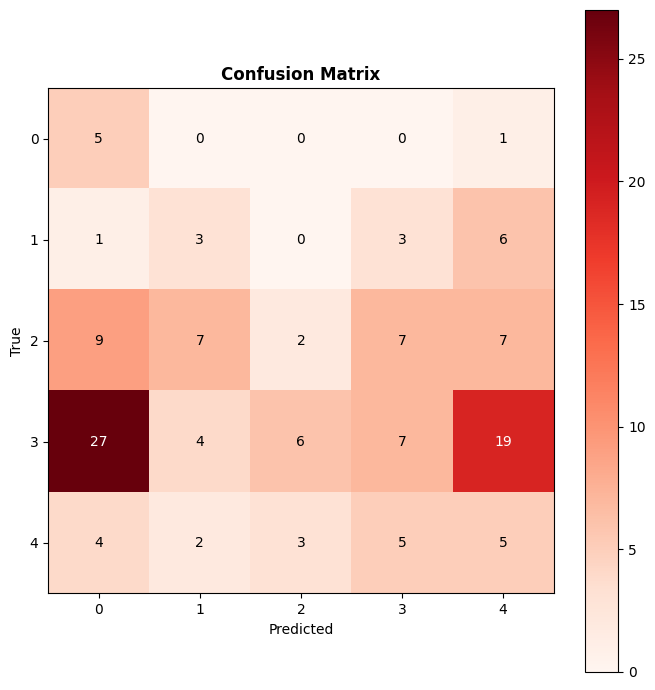

In [138]:
from sklearn.metrics import confusion_matrix


pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 7))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)))
plt.yticks(range(len(matrix)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

#### Precision и recall для каждого класса

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=y_encoder.classes_))

              precision    recall  f1-score   support

           A       0.11      0.83      0.19         6
           C       0.19      0.23      0.21        13
           H       0.18      0.06      0.09        32
           N       0.32      0.11      0.16        63
           S       0.13      0.26      0.18        19

    accuracy                           0.17       133
   macro avg       0.19      0.30      0.17       133
weighted avg       0.24      0.17      0.15       133



- Модель предсказывает Angry слишком часто, но действительно старается его найти. Это прямое следствие весов классов — модель переучилась искать редкий класс, жертвуя точностью
- Модель систематически "перебивает" нейтральный класс другими классами (особенно Angry и Sad). Это обратная сторона борьбы с дисбалансом — **модель стала слишком агрессивной**

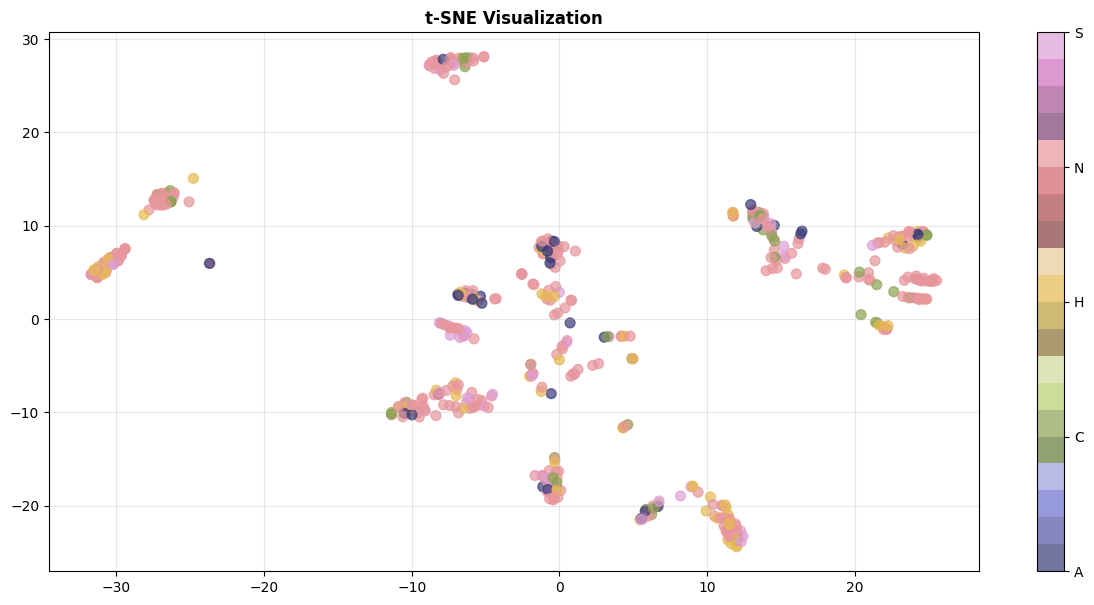

In [117]:
from sklearn.manifold import TSNE

X = train_data[feature_cols].copy()
y = train_data['emotionIndex'].copy()

np.random.seed(0)
random_indices = np.random.choice(len(X), size = 500, replace = False)

X_sample = X.iloc[random_indices]
y_sample = y.iloc[random_indices]


tsne = TSNE(n_components = 2, random_state = 0, perplexity = 30, early_exaggeration = 12)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(15, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab20b', s=50, alpha=0.7)
plt.title('t-SNE Visualization', fontweight='bold')

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(y_encoder.classes_)

plt.grid(alpha=0.3)
plt.show()

## Выводы и наблюдения

- Главная проблема — **сильный дисбаланс классов**. Класс N (нейтральный) доминирует, а остальные (особенно "Angry" и "Sad") представлены в очень малом количестве

- Матрица ошибок показывает, что "веса классов перестарались". Модель научилась бояться ошибаться на редких классах настолько, что начала жертвовать точностью на всех классах

- Визуализация признаков с помощью **t-SNE** наглядно показывает большое перекрытие кластеров разных эмоций. Это объясняет, почему даже лучшая модель с трудом их разделяет — данные изначально не обладают четкой разделимостью